Device: cuda
Rows after merge: 34,989
Labels: {1: 17497, 0: 17492}
Features (21): ['T_res', 'T_res_abs', 'T_res_sq', 'T_roll_mean', 'T_roll_std', 'T_roll_max', 'T_delta', 'Tdew_res', 'Tdew_res_abs', 'Tdew_res_sq', 'Tdew_roll_mean', 'Tdew_roll_std', 'Tdew_roll_max', 'Tdew_delta', 'rh_res', 'rh_res_abs', 'rh_res_sq', 'rh_roll_mean', 'rh_roll_std', 'rh_roll_max', 'rh_delta']
Windows — train: 7,433  val: 1,311

TST | features=21 → d=64 | layers=3 | params=104,226

  Ep |   TrLoss   TrAcc   TrF1 |   VaLoss   VaAcc   VaF1
─────────────────────────────────────────────────────────────────
   1 |   0.1841 50.32% 0.6240 |   0.1747 51.93% 0.4906  ✔
   2 |   0.1751 51.63% 0.4619 |   0.1723 54.06% 0.4263  (1/8)
   3 |   0.1725 53.51% 0.5499 |   0.1697 57.35% 0.5729  ✔
   4 |   0.1694 56.34% 0.5625 |   0.1650 61.30% 0.5736  ✔
   5 |   0.1620 60.94% 0.5908 |   0.1506 66.95% 0.6158  ✔
   6 |   0.1463 67.69% 0.6385 |   0.1304 73.78% 0.6808  ✔
   7 |   0.1320 72.98% 0.6906 |   0.1177 77.55% 0.7340  ✔
  

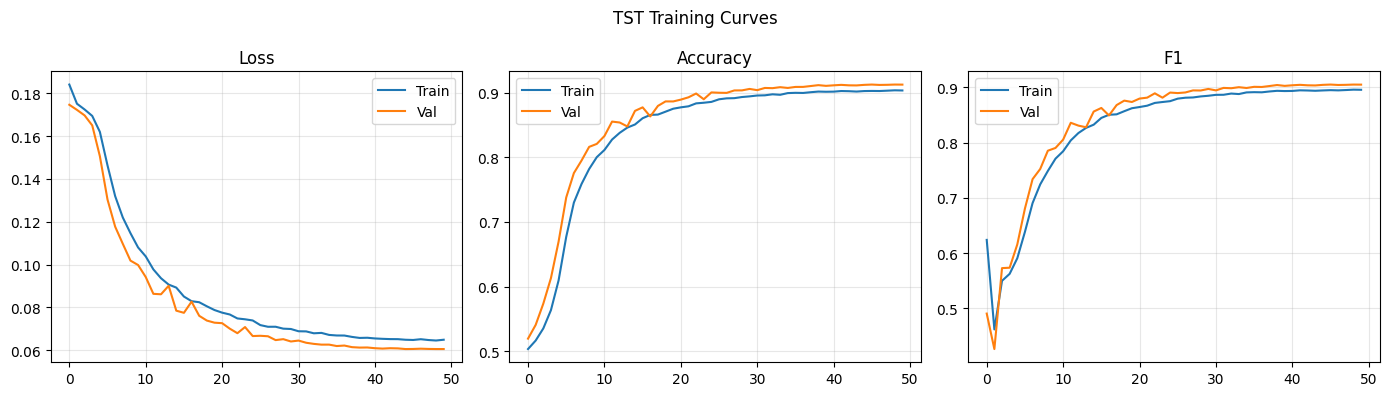

✅ Saved to /content/tst_ckpt


In [ ]:
# ============================================================
# CELL 1 — TRAINING
# Upload: 8months_balanced_faults.xlsx, 8monthsdt_predictions.xlsx
# ============================================================

!pip install -q openpyxl

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pickle, os, warnings
warnings.filterwarnings('ignore')

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = '/content/tst_ckpt'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Device: {DEVICE}')

# ── CONFIG ───────────────────────────────────────────────────
TRAIN_SENSOR_FILE = '/content/8monthsmultisensor_faults.xlsx'
TRAIN_DT_FILE     = '/content/8monthsdt_predictionsonly.xlsx'

SENSOR_COLS = ['T (degC)', 'Tdew (degC)', 'rh (%)']
DT_COLS     = ['T_pred',   'Td_pred',     'RH_pred']
TIMESTAMP   = 'Date Time'
LABEL_COL   = 'binary_label'

# WHY these values:
# Faults are SHORT BURSTS of ~3-5 timesteps scattered through clean readings.
# W=64 caused every window to contain both classes equally → majority vote = noise → ~53% acc.
# W=16 (2.7 hrs context) captures a full fault burst with surrounding clean context.
# Per-timestep prediction: TST sees 16 steps of context, outputs a label for EVERY step.
WINDOW_SIZE = 16    # 16 steps × 10 min = 2.7 hrs of context
STRIDE      = 4     # 75% overlap → dense coverage of fault boundaries
ROLL_W      = 6     # rolling stats window = 1 hr context for residual features

D_MODEL    = 64
N_HEADS    = 4      # D_MODEL must be divisible by N_HEADS
N_LAYERS   = 3
D_FF       = 128
DROPOUT    = 0.1
BATCH_SIZE = 256
EPOCHS     = 50
LR         = 1e-3
VAL_SPLIT  = 0.15
PATIENCE   = 8
SEED       = 42
# ────────────────────────────────────────────────────────────

torch.manual_seed(SEED); np.random.seed(SEED)


# ── 1. Load & align ──────────────────────────────────────────
sens = pd.read_excel(TRAIN_SENSOR_FILE)
dt   = pd.read_excel(TRAIN_DT_FILE)
sens[TIMESTAMP] = pd.to_datetime(sens[TIMESTAMP], dayfirst=True)
dt[TIMESTAMP]   = pd.to_datetime(dt[TIMESTAMP])

df = pd.merge(
    sens[[TIMESTAMP] + SENSOR_COLS + [LABEL_COL]],
    dt[[TIMESTAMP]   + DT_COLS],
    on=TIMESTAMP, how='inner'
).sort_values(TIMESTAMP).reset_index(drop=True)

print(f'Rows after merge: {len(df):,}')
print(f'Labels: {df[LABEL_COL].value_counts().to_dict()}')


# ── 2. Feature engineering ───────────────────────────────────
# For each sensor: residual + rolling stats on residual + sensor delta
# This gives the TST strong signals to detect drift (roll_mean grows),
# spikes (res_abs spikes), stuck_at (delta=0, res grows), replay (large res).

def build_features(df, sensor_cols, dt_cols, roll_w):
    cols, names = [], []
    for sc, dc in zip(sensor_cols, dt_cols):
        px  = sc.split()[0]
        res = df[sc] - df[dc]
        cols += [
            res.values,
            res.abs().values,
            (res**2).values,
            res.rolling(roll_w, min_periods=1).mean().values,
            res.rolling(roll_w, min_periods=1).std().fillna(0).values,
            res.abs().rolling(roll_w, min_periods=1).max().values,
            df[sc].diff().fillna(0).values,   # rate of change of raw sensor
        ]
        names += [f'{px}_res', f'{px}_res_abs', f'{px}_res_sq',
                  f'{px}_roll_mean', f'{px}_roll_std', f'{px}_roll_max', f'{px}_delta']
    return np.stack(cols, axis=1).astype(np.float32), names

X_raw, feat_names = build_features(df, SENSOR_COLS, DT_COLS, ROLL_W)
y_all  = df[LABEL_COL].values.astype(np.int64)
N_FEAT = X_raw.shape[1]
print(f'Features ({N_FEAT}): {feat_names}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

pickle.dump(scaler,     open(f'{SAVE_DIR}/scaler.pkl',  'wb'))
pickle.dump(feat_names, open(f'{SAVE_DIR}/feats.pkl',   'wb'))
pickle.dump({'W': WINDOW_SIZE, 'S': STRIDE, 'F': N_FEAT, 'ROLL_W': ROLL_W,
             'D': D_MODEL, 'H': N_HEADS, 'L': N_LAYERS, 'FF': D_FF, 'DO': DROPOUT},
            open(f'{SAVE_DIR}/cfg.pkl', 'wb'))


# ── 3. Dataset ───────────────────────────────────────────────
# KEY CHANGE from v1: predict label for EVERY timestep in the window.
# The TST sees 16 steps of context and outputs 16 predictions.
# This is fundamentally better for short fault bursts (avg 3-5 steps).

class FaultDataset(Dataset):
    def __init__(self, X, y, W, S):
        wins, labs = [], []
        for s in range(0, len(X) - W + 1, S):
            wins.append(X[s:s+W])
            labs.append(y[s:s+W])         # (W,) — label every timestep
        self.X = torch.tensor(np.stack(wins), dtype=torch.float32)  # (N, W, F)
        self.y = torch.tensor(np.stack(labs), dtype=torch.long)     # (N, W)
    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

full_ds = FaultDataset(X_scaled, y_all, WINDOW_SIZE, STRIDE)
n_val   = int(len(full_ds) * VAL_SPLIT)
n_train = len(full_ds) - n_val
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_val], generator=torch.Generator().manual_seed(SEED)
)
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Windows — train: {n_train:,}  val: {n_val:,}')


# ── 4. TST ───────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=512, drop=0.1):
        super().__init__()
        self.drop = nn.Dropout(drop)
        pe  = torch.zeros(max_len, d)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-np.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return self.drop(x + self.pe[:, :x.size(1)])

class TST(nn.Module):
    """
    Temporal Signal Transformer — per-timestep binary fault detection.

    Input  : (B, W, F)  — window of residual-augmented features
    Output : (B, W, 2)  — logits for every timestep in the window

    This per-timestep output is the critical fix:
    instead of one label per window (which averaged away short faults),
    we predict a label at every position, giving the TST local context
    while still classifying each individual timestep.
    """
    def __init__(self, n_feat, d, n_heads, n_layers, d_ff, drop):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(n_feat, d), nn.LayerNorm(d))
        self.pe   = PositionalEncoding(d, drop=drop)
        enc = nn.TransformerEncoderLayer(d, n_heads, d_ff, drop,
                                          batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc, n_layers, enable_nested_tensor=False)
        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d // 2),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d // 2, 2)     # 2 classes at every timestep
        )
    def forward(self, x):            # x: (B, W, F)
        x = self.proj(x)             # (B, W, d)
        x = self.pe(x)
        x = self.enc(x)              # (B, W, d)
        return self.head(x)          # (B, W, 2)  ← every timestep gets logits

model = TST(N_FEAT, D_MODEL, N_HEADS, N_LAYERS, D_FF, DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTST | features={N_FEAT} → d={D_MODEL} | layers={N_LAYERS} | params={n_params:,}')


# ── 5. Loss, optimiser ───────────────────────────────────────
# FocalLoss focuses on hard borderline timesteps (fault boundary steps)
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, logits, targets):
        # logits: (B*W, 2)  targets: (B*W,)
        ce = nn.functional.cross_entropy(logits, targets, reduction='none')
        return ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()

criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_loader), epochs=EPOCHS
)


# ── 6. Train / val loop ──────────────────────────────────────
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_p, all_y = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)      # (B,W,F), (B,W)
            logits = model(xb)                           # (B,W,2)
            B, W, C = logits.shape
            loss = criterion(logits.reshape(B*W, C), yb.reshape(B*W))
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            total_loss += loss.item() * B * W
            all_p.append(logits.reshape(B*W, C).argmax(1).cpu())
            all_y.append(yb.reshape(B*W).cpu())
    p = torch.cat(all_p).numpy(); y = torch.cat(all_y).numpy()
    return total_loss / len(y), (p==y).mean(), f1_score(y, p, zero_division=0)

hist = {'tl':[],'vl':[],'ta':[],'va':[],'tf':[],'vf':[]}
best_f1, pat = -1.0, 0

print(f'\n{"Ep":>4} | {"TrLoss":>8} {"TrAcc":>7} {"TrF1":>6} | {"VaLoss":>8} {"VaAcc":>7} {"VaF1":>6}')
print('─' * 65)

for ep in range(1, EPOCHS+1):
    tl, ta, tf = run_epoch(train_loader, train=True)
    vl, va, vf = run_epoch(val_loader,   train=False)
    for k,v in zip(['tl','ta','tf','vl','va','vf'],[tl,ta,tf,vl,va,vf]):
        hist[k].append(v)
    print(f'{ep:>4} | {tl:>8.4f} {ta:>6.2%} {tf:>6.4f} | {vl:>8.4f} {va:>6.2%} {vf:>6.4f}', end='')
    if vf > best_f1:
        best_f1 = vf
        torch.save(model.state_dict(), f'{SAVE_DIR}/best_model.pt')
        pat = 0; print('  ✔')
    else:
        pat += 1; print(f'  ({pat}/{PATIENCE})')
        if pat >= PATIENCE: print(f'Early stop at ep {ep}.'); break

print(f'\nBest val F1: {best_f1:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (tk, vk, title) in zip(axes, [('tl','vl','Loss'),('ta','va','Accuracy'),('tf','vf','F1')]):
    ax.plot(hist[tk], label='Train'); ax.plot(hist[vk], label='Val')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('TST Training Curves'); plt.tight_layout(); plt.show()
print(f'✅ Saved to {SAVE_DIR}')

In [ ]:
# ============================================================
# CELL 2 — INFERENCE
# Upload: test_no_labels.xlsx, testdt_predictionsonly.xlsx
# ============================================================

import numpy as np, pandas as pd, torch, torch.nn as nn, pickle, warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = '/content/tst_ckpt'

cfg        = pickle.load(open(f'{SAVE_DIR}/cfg.pkl',   'rb'))
scaler     = pickle.load(open(f'{SAVE_DIR}/scaler.pkl','rb'))
feat_names = pickle.load(open(f'{SAVE_DIR}/feats.pkl', 'rb'))
W, S, F    = cfg['W'], cfg['S'], cfg['F']
ROLL_W     = cfg['ROLL_W']

SENSOR_COLS = ['T (degC)', 'Tdew (degC)', 'rh (%)']
DT_COLS     = ['T_pred',   'Td_pred',     'RH_pred']
TIMESTAMP   = 'Date Time'

# Rebuild TST (identical to Cell 1)
class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=512, drop=0.1):
        super().__init__()
        self.drop = nn.Dropout(drop)
        pe  = torch.zeros(max_len, d)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-np.log(10000.0) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return self.drop(x + self.pe[:, :x.size(1)])

class TST(nn.Module):
    def __init__(self, n_feat, d, n_heads, n_layers, d_ff, drop):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(n_feat, d), nn.LayerNorm(d))
        self.pe   = PositionalEncoding(d, drop=drop)
        enc = nn.TransformerEncoderLayer(d, n_heads, d_ff, drop,
                                          batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc, n_layers, enable_nested_tensor=False)
        self.head = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d, d//2), nn.GELU(),
            nn.Dropout(drop), nn.Linear(d//2, 2)
        )
    def forward(self, x):
        return self.head(self.enc(self.pe(self.proj(x))))

model = TST(F, cfg['D'], cfg['H'], cfg['L'], cfg['FF'], cfg['DO']).to(DEVICE)
model.load_state_dict(torch.load(f'{SAVE_DIR}/best_model.pt', map_location=DEVICE))
model.eval()
print('Model loaded ✔')

# Load & feature-engineer test data (same pipeline as training)
sens = pd.read_excel('/content/testmultisensor_faults no labels.xlsx')
dt   = pd.read_excel('/content/dt_test_predictionsonly.xlsx')
sens[TIMESTAMP] = pd.to_datetime(sens[TIMESTAMP], dayfirst=True)
dt[TIMESTAMP]   = pd.to_datetime(dt[TIMESTAMP])

df = pd.merge(
    sens[[TIMESTAMP] + SENSOR_COLS],
    dt[[TIMESTAMP]   + DT_COLS],
    on=TIMESTAMP, how='inner'
).sort_values(TIMESTAMP).reset_index(drop=True)

def build_features(df, sensor_cols, dt_cols, roll_w):
    cols = []
    for sc, dc in zip(sensor_cols, dt_cols):
        res = df[sc] - df[dc]
        cols += [res.values, res.abs().values, (res**2).values,
                 res.rolling(roll_w, min_periods=1).mean().values,
                 res.rolling(roll_w, min_periods=1).std().fillna(0).values,
                 res.abs().rolling(roll_w, min_periods=1).max().values,
                 df[sc].diff().fillna(0).values]
    return np.stack(cols, axis=1).astype(np.float32)

X_raw = build_features(df, SENSOR_COLS, DT_COLS, ROLL_W)
X     = scaler.transform(X_raw).astype(np.float32)
print(f'Test timesteps: {len(X):,}')

# Predict: overlapping windows, vote per timestep
# Each timestep collects votes from all windows that include it
vote_sum   = np.zeros((len(X), 2), dtype=np.float32)
vote_count = np.zeros(len(X), dtype=np.int32)

starts = list(range(0, len(X) - W + 1, S))
if len(X) - W not in starts: starts.append(max(0, len(X) - W))

wins_t = torch.tensor(np.stack([X[s:s+W] for s in starts]), dtype=torch.float32)

with torch.no_grad():
    for i in range(0, len(wins_t), 512):
        logits = model(wins_t[i:i+512].to(DEVICE))        # (B, W, 2)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        for j, s in enumerate(starts[i:i+512]):
            vote_sum[s:s+W]   += probs[j]
            vote_count[s:s+W] += 1

vote_count = vote_count.clip(min=1)
norm_probs = vote_sum / vote_count[:, None]
preds      = np.argmax(norm_probs, axis=1)
p_faulty   = norm_probs[:, 1]

out = pd.DataFrame({
    'Date Time':       df[TIMESTAMP].values,
    'predicted_label': preds,
    'predicted_class': np.where(preds==1, 'faulty', 'clean'),
    'p_faulty':        np.round(p_faulty, 4),
    'p_clean':         np.round(norm_probs[:,0], 4)
})
out.to_csv('TST predicted_labels.csv', index=False)
print(f' predicted_labels.csv saved')
print(out['predicted_class'].value_counts().to_string())



Model loaded ✔
Test timesteps: 3,120
 predicted_labels.csv saved
predicted_class
clean     1803
faulty    1317


In [ ]:

# CELL 3 — EVALUATION
#  test_balanced_faults.xlsx
# ============================================================

import numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
warnings.filterwarnings('ignore')

gt   = pd.read_excel('/content/testmultisensor_faults.xlsx')
pred = pd.read_csv('/content/TST predicted_labels.csv')
gt['Date Time']   = pd.to_datetime(gt['Date Time'],   dayfirst=True)
pred['Date Time'] = pd.to_datetime(pred['Date Time'])

merged = pd.merge(
    pred[['Date Time','predicted_label','p_faulty']],
    gt[['Date Time','binary_label','fault_label']],
    on='Date Time', how='inner'
)
y_true = merged['binary_label'].values
y_pred = merged['predicted_label'].values
y_prob = merged['p_faulty'].values
ftype  = merged['fault_label'].values

# ── Metrics ──────────────────────────────────────────────────
acc     = accuracy_score(y_true, y_pred)
f1      = f1_score(y_true, y_pred, zero_division=0)
prec    = precision_score(y_true, y_pred, zero_division=0)
rec     = recall_score(y_true, y_pred, zero_division=0)
roc     = roc_auc_score(y_true, y_prob)
ap      = average_precision_score(y_true, y_prob)
tn,fp,fn,tp = confusion_matrix(y_true, y_pred).ravel()


print('   TST BINARY FAULT DETECTION — RESULTS')
print('═'*55)
print(f'  Accuracy          : {acc:.4f}  ({acc:.2%})')
print(f'  F1 (faulty=pos)   : {f1:.4f}')
print(f'  Precision         : {prec:.4f}')
print(f'  Recall            : {rec:.4f}  ← % faults caught')
print(f'  TN={tn} FP={fp} FN={fn} TP={tp}')




   TST BINARY FAULT DETECTION — RESULTS
═══════════════════════════════════════════════════════
  Accuracy          : 0.9144  (91.44%)
  F1 (faulty=pos)   : 0.9073
  Precision         : 0.9924
  Recall            : 0.8357  ← % faults caught
  TN=1546 FP=10 FN=257 TP=1307


Device: cuda
Rows: 34,989  Labels: {1: 17497, 0: 17492}
Features: 27  |  Patches per window: 15
Windows — train: 7,429  val: 1,311

PatchTST | feat=27 patches=15 d=128 layers=4 params=423,106

  Ep |   TrLoss   TrAcc   TrF1 |   VaLoss   VaAcc   VaF1
─────────────────────────────────────────────────────────────────
   1 |   0.1822 50.37% 0.5183 |   0.1746 51.73% 0.5212  ✔
   2 |   0.1746 52.66% 0.5265 |   0.1706 55.96% 0.6000  ✔
   3 |   0.1711 55.51% 0.5526 |   0.1678 58.81% 0.6207  ✔
   4 |   0.1685 57.79% 0.5746 |   0.1650 61.25% 0.5930  (1/8)
   5 |   0.1654 60.22% 0.5985 |   0.1607 63.19% 0.6145  (2/8)
   6 |   0.1610 62.58% 0.6123 |   0.1544 66.56% 0.6535  ✔
   7 |   0.1552 65.70% 0.6323 |   0.1472 69.74% 0.6843  ✔
   8 |   0.1493 68.41% 0.6644 |   0.1424 71.18% 0.6859  ✔
   9 |   0.1453 69.92% 0.6798 |   0.1374 72.79% 0.7149  ✔
  10 |   0.1404 71.49% 0.7018 |   0.1403 71.81% 0.7302  ✔
  11 |   0.1381 72.16% 0.7118 |   0.1279 75.47% 0.7552  ✔
  12 |   0.1317 74.10% 0.7385 |   0.13

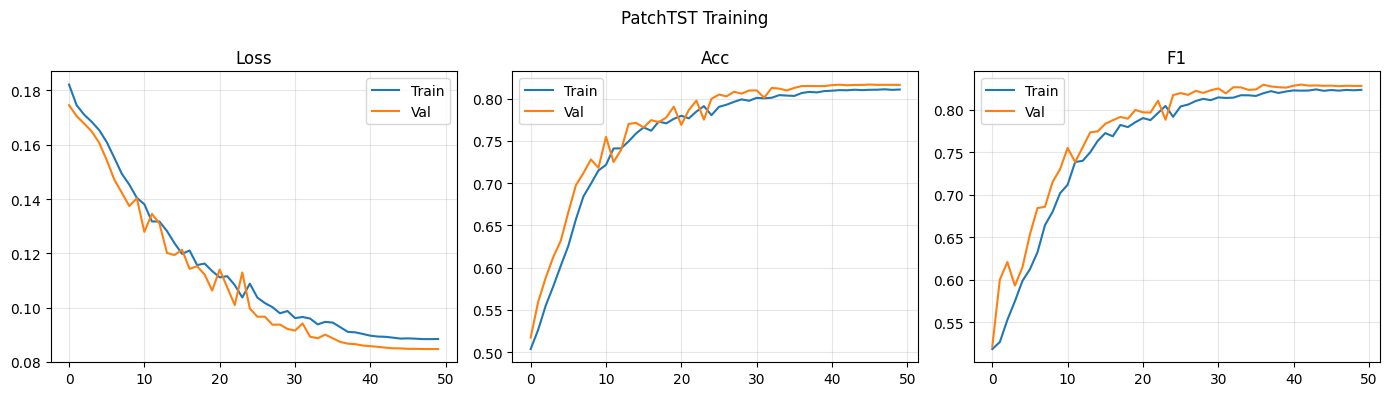

✅ Saved to /content/patchtst_ckpt


In [ ]:
# ============================================================
# CELL 1 — PatchTST TRAINING
#  8months_balanced_faults.xlsx, 8monthsdt_predictions.xlsx
# ============================================================

!pip install -q openpyxl

import numpy as np, pandas as pd, torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pickle, os, warnings
warnings.filterwarnings('ignore')

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = '/content/patchtst_ckpt'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Device: {DEVICE}')

# ── CONFIG ────────────────────────────────────────────────────
TRAIN_SENSOR_FILE = '/content/8monthsmultisensor_faults.xlsx'
TRAIN_DT_FILE     = '/content/8monthsdt_predictionsonly.xlsx'
SENSOR_COLS = ['T (degC)', 'Tdew (degC)', 'rh (%)']
DT_COLS     = ['T_pred',   'Td_pred',     'RH_pred']
TIMESTAMP   = 'Date Time'
LABEL_COL   = 'binary_label'

WINDOW_SIZE = 32   # context window (same as TST/TimesNet — fault bursts are 3-5 steps)
PATCH_LEN   = 4    # each patch covers 4 timesteps = 40 min
PATCH_STRIDE = 2   # patches overlap by 2 steps
STRIDE      = 4    # window stride
ROLL_W      = 6    # rolling stats window

D_MODEL    = 128
N_HEADS    = 4
N_LAYERS   = 4
D_FF       = 128
DROPOUT    = 0.1
BATCH_SIZE = 256
EPOCHS     = 50
LR         = 1e-3
VAL_SPLIT  = 0.15
PATIENCE   = 8
SEED       = 42
# ─────────────────────────────────────────────────────────────

torch.manual_seed(SEED); np.random.seed(SEED)

# ── 1. Load & align ───────────────────────────────────────────
sens = pd.read_excel(TRAIN_SENSOR_FILE)
dt   = pd.read_excel(TRAIN_DT_FILE)
sens[TIMESTAMP] = pd.to_datetime(sens[TIMESTAMP], dayfirst=True)
dt[TIMESTAMP]   = pd.to_datetime(dt[TIMESTAMP], dayfirst=True)
df = pd.merge(
    sens[[TIMESTAMP] + SENSOR_COLS + [LABEL_COL]],
    dt[[TIMESTAMP]   + DT_COLS],
    on=TIMESTAMP, how='inner'
).sort_values(TIMESTAMP).reset_index(drop=True)
print(f'Rows: {len(df):,}  Labels: {df[LABEL_COL].value_counts().to_dict()}')

# ── 2. Feature engineering ────────────────────────────────────
def build_features(df, sensor_cols, dt_cols, roll_w):
    cols = []
    for sc, dc in zip(sensor_cols, dt_cols):
        res = df[sc] - df[dc]
        cols += [df[sc].values,df[dc].values,res.values, res.abs().values, (res**2).values,
                 res.rolling(roll_w, min_periods=1).mean().values,
                 res.rolling(roll_w, min_periods=1).std().fillna(0).values,
                 res.abs().rolling(roll_w, min_periods=1).max().values,
                 df[sc].diff().fillna(0).values]
    return np.stack(cols, axis=1).astype(np.float32)

X_raw = build_features(df, SENSOR_COLS, DT_COLS, ROLL_W)
y_all = df[LABEL_COL].values.astype(np.int64)
N_FEAT = X_raw.shape[1]
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

# Compute number of patches per window
N_PATCHES = (WINDOW_SIZE - PATCH_LEN) // PATCH_STRIDE + 1
print(f'Features: {N_FEAT}  |  Patches per window: {N_PATCHES}')

pickle.dump(scaler, open(f'{SAVE_DIR}/scaler.pkl','wb'))
pickle.dump({'W': WINDOW_SIZE, 'S': STRIDE, 'F': N_FEAT, 'ROLL_W': ROLL_W,
             'PL': PATCH_LEN, 'PS': PATCH_STRIDE, 'NP': N_PATCHES,
             'D': D_MODEL, 'H': N_HEADS, 'L': N_LAYERS, 'FF': D_FF, 'DO': DROPOUT},
            open(f'{SAVE_DIR}/cfg.pkl','wb'))

# ── 3. Dataset ────────────────────────────────────────────────
class FaultDataset(Dataset):
    def __init__(self, X, y, W, S):
        wins, labs = [], []
        for s in range(0, len(X) - W + 1, S):
            wins.append(X[s:s+W])
            labs.append(y[s:s+W])   # per-timestep labels
        self.X = torch.tensor(np.stack(wins), dtype=torch.float32)
        self.y = torch.tensor(np.stack(labs), dtype=torch.long)
    def __len__(self):          return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

full_ds = FaultDataset(X_scaled, y_all, WINDOW_SIZE, STRIDE)
n_val   = int(len(full_ds) * VAL_SPLIT)
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [len(full_ds)-n_val, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Windows — train: {len(train_ds):,}  val: {len(val_ds):,}')

# ── 4. PatchTST ───────────────────────────────────────────────
# Core idea: instead of feeding every single timestep as a token(like TST does), PatchTST groups timesteps into PATCHES first.
# Each patch = 4 timesteps = 40 min of sensor data → 1 token.
# With W=16 and patch_len=4, stride=2 → 7 patch tokens per window.


class PatchTST(nn.Module):
    def __init__(self, n_feat, window, patch_len, patch_stride, d_model,
                 n_heads, n_layers, d_ff, dropout):
        super().__init__()
        self.patch_len    = patch_len
        self.patch_stride = patch_stride
        self.n_patches    = (window - patch_len) // patch_stride + 1

        # Each patch token = flattened patch_len timesteps × n_feat channels
        patch_dim = patch_len * n_feat
        self.patch_embed = nn.Sequential(
            nn.Linear(patch_dim, d_model),
            nn.LayerNorm(d_model)
        )
        # Learnable positional embedding (one per patch position)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        enc = nn.TransformerEncoderLayer(
            d_model, n_heads, d_ff, dropout,
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc, n_layers,
                                                  enable_nested_tensor=False)
        self.drop = nn.Dropout(dropout)

        # Classification head: operates per patch, outputs 2 logits
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 2)
        )
        self.window = window

    def forward(self, x):              # x: (B, W, F)
        B, W, F = x.shape

        # Extract patches: slide patch_len window over time axis
        patches = []
        for i in range(self.n_patches):
            s = i * self.patch_stride
            patches.append(x[:, s:s+self.patch_len, :].reshape(B, -1))
        x_pat = torch.stack(patches, dim=1)        # (B, N_patches, patch_len*F)

        # Embed + positional encoding
        x_pat = self.patch_embed(x_pat) + self.pos_embed   # (B, N_patches, d_model)
        x_pat = self.drop(x_pat)

        # Transformer over patches
        x_pat = self.transformer(x_pat)                    # (B, N_patches, d_model)

        # Per-patch logits
        logits_patch = self.head(x_pat)                    # (B, N_patches, 2)

        # Upsample patch logits back to per-timestep:
        # repeat each patch's logit for its corresponding timesteps
        # Simple approach: repeat_interleave by patch_stride, trim to W
        logits_ts = logits_patch.repeat_interleave(self.patch_stride, dim=1)
        # Pad if needed to reach W timesteps
        if logits_ts.shape[1] < W:
            pad = logits_ts[:, -1:, :].expand(B, W - logits_ts.shape[1], 2)
            logits_ts = torch.cat([logits_ts, pad], dim=1)
        return logits_ts[:, :W, :]                         # (B, W, 2)


model = PatchTST(N_FEAT, WINDOW_SIZE, PATCH_LEN, PATCH_STRIDE,
                 D_MODEL, N_HEADS, N_LAYERS, D_FF, DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nPatchTST | feat={N_FEAT} patches={N_PATCHES} d={D_MODEL} layers={N_LAYERS} params={n_params:,}')

# ── 5. Focal loss + optimiser ─────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__(); self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        return ((1 - torch.exp(-ce)) ** self.gamma * ce).mean()

criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_loader), epochs=EPOCHS)

# ── 6. Train / val loop ───────────────────────────────────────
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_p, all_y = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)                      # (B, W, 2)
            B, W, C = logits.shape
            loss = criterion(logits.reshape(B*W, C), yb.reshape(B*W))
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            total_loss += loss.item() * B * W
            all_p.append(logits.reshape(B*W,C).argmax(1).cpu())
            all_y.append(yb.reshape(B*W).cpu())
    p = torch.cat(all_p).numpy(); y = torch.cat(all_y).numpy()
    return total_loss/len(y), (p==y).mean(), f1_score(y, p, zero_division=0)

hist = {'tl':[],'vl':[],'ta':[],'va':[],'tf':[],'vf':[]}
best_f1, pat = -1.0, 0
print(f'\n{"Ep":>4} | {"TrLoss":>8} {"TrAcc":>7} {"TrF1":>6} | {"VaLoss":>8} {"VaAcc":>7} {"VaF1":>6}')
print('─'*65)
for ep in range(1, EPOCHS+1):
    tl,ta,tf = run_epoch(train_loader, train=True)
    vl,va,vf = run_epoch(val_loader,   train=False)
    for k,v in zip(['tl','ta','tf','vl','va','vf'],[tl,ta,tf,vl,va,vf]):
        hist[k].append(v)
    print(f'{ep:>4} | {tl:>8.4f} {ta:>6.2%} {tf:>6.4f} | {vl:>8.4f} {va:>6.2%} {vf:>6.4f}', end='')
    if vf > best_f1:
        best_f1 = vf
        torch.save(model.state_dict(), f'{SAVE_DIR}/best_model.pt')
        pat = 0; print('  ✔')
    else:
        pat += 1; print(f'  ({pat}/{PATIENCE})')
        if pat >= PATIENCE: print(f'Early stop ep {ep}.'); break

print(f'Best val F1: {best_f1:.4f}')
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax,(tk,vk,title) in zip(axes,[('tl','vl','Loss'),('ta','va','Acc'),('tf','vf','F1')]):
    ax.plot(hist[tk],label='Train'); ax.plot(hist[vk],label='Val')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('PatchTST Training'); plt.tight_layout(); plt.show()
print(f'✅ Saved to {SAVE_DIR}')

In [ ]:
# ============================================================
# CELL 2 — PatchTST INFERENCE
# ============================================================

import numpy as np, pandas as pd, torch, torch.nn as nn
import torch.nn.functional as F
import pickle, warnings, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = '/content/patchtst_ckpt'
cfg    = pickle.load(open(f'{SAVE_DIR}/cfg.pkl',   'rb'))
scaler = pickle.load(open(f'{SAVE_DIR}/scaler.pkl','rb'))
W, S, F_DIM = cfg['W'], cfg['S'], cfg['F']
ROLL_W = cfg['ROLL_W']
SENSOR_COLS = ['T (degC)', 'Tdew (degC)', 'rh (%)']
DT_COLS     = ['T_pred',   'Td_pred',     'RH_pred']
TIMESTAMP   = 'Date Time'

# Rebuild PatchTST
class PatchTST(nn.Module):
    def __init__(self, n_feat, window, patch_len, patch_stride, d_model,
                 n_heads, n_layers, d_ff, dropout):
        super().__init__()
        self.patch_len    = patch_len
        self.patch_stride = patch_stride
        self.n_patches    = (window - patch_len) // patch_stride + 1
        patch_dim = patch_len * n_feat
        self.patch_embed = nn.Sequential(nn.Linear(patch_dim, d_model), nn.LayerNorm(d_model))
        self.pos_embed   = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        enc = nn.TransformerEncoderLayer(d_model, n_heads, d_ff, dropout,
                                          batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, n_layers, enable_nested_tensor=False)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model//2),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(d_model//2, 2)
        )
        self.window = window
    def forward(self, x):
        B, W, F = x.shape
        patches = []
        for i in range(self.n_patches):
            s = i * self.patch_stride
            patches.append(x[:, s:s+self.patch_len, :].reshape(B, -1))
        x_pat = torch.stack(patches, dim=1)
        x_pat = self.drop(self.patch_embed(x_pat) + self.pos_embed)
        x_pat = self.transformer(x_pat)
        lp    = self.head(x_pat).repeat_interleave(self.patch_stride, dim=1)
        if lp.shape[1] < W:
            lp = torch.cat([lp, lp[:,-1:,:].expand(B, W-lp.shape[1], 2)], dim=1)
        return lp[:, :W, :]

model = PatchTST(F_DIM, W, cfg['PL'], cfg['PS'], cfg['D'],
                 cfg['H'], cfg['L'], cfg['FF'], cfg['DO']).to(DEVICE)
model.load_state_dict(torch.load(f'{SAVE_DIR}/best_model.pt', map_location=DEVICE))
model.eval(); print('Model loaded ✔')

def build_features(df, sensor_cols, dt_cols, roll_w):
    cols = []
    for sc, dc in zip(sensor_cols, dt_cols):
        res = df[sc] - df[dc]
        cols += [df[sc].values,df[dc].values,res.values, res.abs().values, (res**2).values,
                 res.rolling(roll_w,min_periods=1).mean().values,
                 res.rolling(roll_w,min_periods=1).std().fillna(0).values,
                 res.abs().rolling(roll_w,min_periods=1).max().values,
                 df[sc].diff().fillna(0).values]
    return np.stack(cols, axis=1).astype(np.float32)

sens = pd.read_excel('/content/testmultisensor_faults no labels.xlsx')
dt   = pd.read_excel('/content/dt_test_predictionsonly.xlsx')
sens[TIMESTAMP] = pd.to_datetime(sens[TIMESTAMP], dayfirst=True)
dt[TIMESTAMP]   = pd.to_datetime(dt[TIMESTAMP], dayfirst=True)
df = pd.merge(sens[[TIMESTAMP]+SENSOR_COLS], dt[[TIMESTAMP]+DT_COLS],
              on=TIMESTAMP, how='inner').sort_values(TIMESTAMP).reset_index(drop=True)
X = scaler.transform(build_features(df, SENSOR_COLS, DT_COLS, ROLL_W)).astype(np.float32)
print(f'Test timesteps: {len(X):,}')

vote_sum   = np.zeros((len(X), 2), dtype=np.float32)
vote_count = np.zeros(len(X), dtype=np.int32)
starts = list(range(0, len(X)-W+1, S))
if len(X)-W not in starts: starts.append(max(0, len(X)-W))
wins_t = torch.tensor(np.stack([X[s:s+W] for s in starts]), dtype=torch.float32)
with torch.no_grad():
    for i in range(0, len(wins_t), 512):
        probs = torch.softmax(model(wins_t[i:i+512].to(DEVICE)), dim=-1).cpu().numpy()
        for j, s in enumerate(starts[i:i+512]):
            vote_sum[s:s+W] += probs[j]; vote_count[s:s+W] += 1

norm_probs = vote_sum / vote_count[:,None].clip(min=1)
preds    = np.argmax(norm_probs, axis=1)
p_faulty = norm_probs[:,1]
out = pd.DataFrame({'Date Time': df[TIMESTAMP].values, 'predicted_label': preds,
                    'predicted_class': np.where(preds==1,'faulty','clean'),
                    'p_faulty': np.round(p_faulty,4), 'p_clean': np.round(norm_probs[:,0],4)})
out.to_csv('predicted_labels.csv', index=False)
print(' predicted_labels.csv saved')
print(out['predicted_class'].value_counts().to_string())


Model loaded ✔
Test timesteps: 3,120
 predicted_labels.csv saved
predicted_class
faulty    1696
clean     1424


In [ ]:
#PatchTST Metrics
import numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report)
warnings.filterwarnings('ignore')

gt   = pd.read_excel('/content/testmultisensor_faults.xlsx')
pred = pd.read_csv('/content/predicted_labels.csv')
gt['Date Time']   = pd.to_datetime(gt['Date Time'], dayfirst=True)
pred['Date Time'] = pd.to_datetime(pred['Date Time'])

merged = pd.merge(pred[['Date Time','predicted_label']],
                  gt[['Date Time','binary_label','fault_label']],
                  on='Date Time', how='inner')

y_true = merged['binary_label'].values
y_pred = merged['predicted_label'].values

# ── Metrics ──────────────────────────────────────────────────
print(f'PatchTST Metrics')
print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
print(f'F1        : {f1_score(y_true, y_pred, zero_division=0):.4f}')
print(f'Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}')
print()




PatchTST Metrics
Accuracy  : 0.7904
F1        : 0.7994
Precision : 0.7683
Recall    : 0.8331



Device: cuda
Rows: 34,989  |  Labels: {1: 17497, 0: 17492}
Features: 21
Windows — train: 7,433  val: 1,311

Loading thuml/timer-base-84m ...


config.json:   0%|          | 0.00/682 [00:00<?, ?B/s]

configuration_timer.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/thuml/timer-base-84m:
- configuration_timer.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Config d_model = 1024


...

ts_generation_mixin.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/thuml/timer-base-84m:
- ts_generation_mixin.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/thuml/timer-base-84m:
- modeling_timer.py
- ts_generation_mixin.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Loading weights manually (bypasses transformers version issues)...


model.safetensors:   0%|          | 0.00/337M [00:00<?, ?B/s]

Weights loaded ✔  missing=115  unexpected=116
  First 3 missing   : ['embed_layer.emb.weight', 'layers.0.self_attn.q_proj.weight', 'layers.0.self_attn.q_proj.bias']
  First 3 unexpected: ['lm_heads.0.weight', 'model.embed_layer.emb.weight', 'model.layers.0.ffn_layer.down_proj.weight']
Timer-S1 frozen ✔  |  d_model = 1024
Total: 84,201,858  |  Trainable: 158,082

  Ep |   TrLoss   TrAcc   TrF1 |   VaLoss   VaAcc   VaF1
────────────────────────────────────────────────────────────
   1 |   0.1793 52.08% 0.5000 |   0.1707 56.25% 0.4832  ✔
   2 |   0.1680 58.06% 0.5592 |   0.1630 62.25% 0.6065  ✔
   3 |   0.1585 63.33% 0.6162 |   0.1527 66.58% 0.6148  ✔
   4 |   0.1466 67.98% 0.6530 |   0.1409 70.15% 0.6698  ✔
   5 |   0.1353 71.82% 0.6890 |   0.1323 73.00% 0.6667  (1/8)
   6 |   0.1270 74.59% 0.7110 |   0.1245 75.82% 0.7169  ✔
   7 |   0.1212 76.57% 0.7323 |   0.1204 77.26% 0.7358  ✔
   8 |   0.1171 77.82% 0.7468 |   0.1176 77.81% 0.7463  ✔
   9 |   0.1138 78.58% 0.7569 |   0.1137 78.80% 0

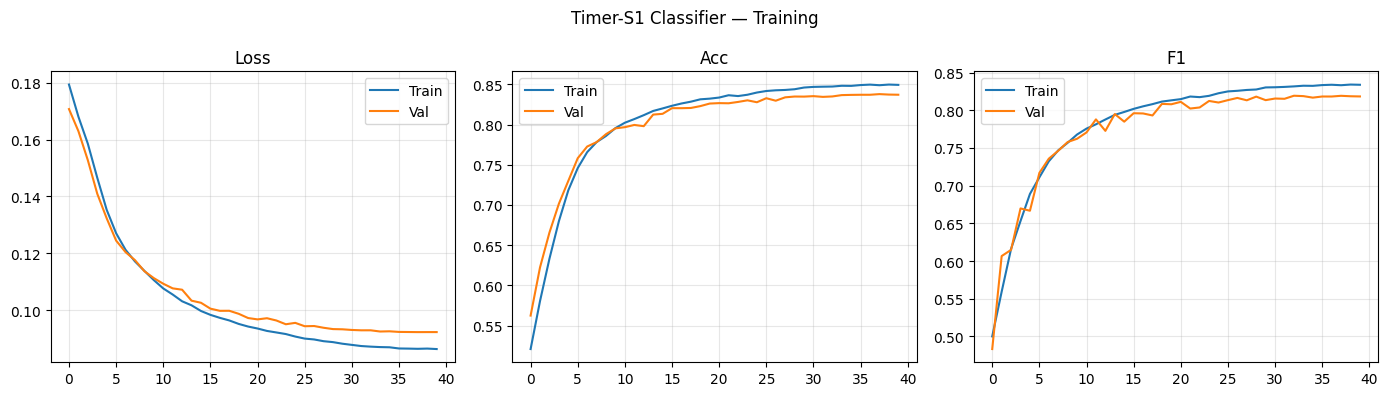

✅ Saved → /content/timer_ckpt


In [ ]:
# ============================================================
# CELL 1 — Timer-S1 AS CLASSIFIER  (training)  ← FIXED
# Upload: 8months_balanced_faults.xlsx, 8monthsdt_predictions.xlsx
# ============================================================
!pip install -q transformers huggingface_hub openpyxl

import numpy as np, pandas as pd, torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from transformers import AutoConfig
from transformers.dynamic_module_utils import get_class_from_dynamic_module
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt, pickle, os, warnings
warnings.filterwarnings('ignore')

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = '/content/timer_ckpt'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Device: {DEVICE}')

# ── CONFIG ────────────────────────────────────────────────────
SENSOR_COLS = ['T (degC)', 'Tdew (degC)', 'rh (%)']
DT_COLS     = ['T_pred',   'Td_pred',     'RH_pred']
TIMESTAMP   = 'Date Time'
LABEL_COL   = 'binary_label'
TIMER_MODEL = 'thuml/timer-base-84m'
WINDOW_SIZE = 16
STRIDE      = 4
ROLL_W      = 6
D_HEAD      = 128
DROPOUT     = 0.1
BATCH_SIZE  = 128
EPOCHS      = 40
LR          = 3e-4
VAL_SPLIT   = 0.15
PATIENCE    = 8
SEED        = 42
torch.manual_seed(SEED); np.random.seed(SEED)

# ── 1. Load & align ───────────────────────────────────────────
sens = pd.read_excel('/content/8monthsmultisensor_faults.xlsx')
dt   = pd.read_excel('/content/8monthsdt_predictionsonly.xlsx')
sens[TIMESTAMP] = pd.to_datetime(sens[TIMESTAMP], dayfirst=True)
dt[TIMESTAMP]   = pd.to_datetime(dt[TIMESTAMP])
df = pd.merge(
    sens[[TIMESTAMP]+SENSOR_COLS+[LABEL_COL]],
    dt[[TIMESTAMP]+DT_COLS],
    on=TIMESTAMP, how='inner'
).sort_values(TIMESTAMP).reset_index(drop=True)
print(f'Rows: {len(df):,}  |  Labels: {df[LABEL_COL].value_counts().to_dict()}')

# ── 2. Feature engineering ────────────────────────────────────
def build_features(df, scols, dcols, rw):
    cols = []
    for sc, dc in zip(scols, dcols):
        res = df[sc] - df[dc]
        cols += [res.values, res.abs().values, (res**2).values,
                 res.rolling(rw, min_periods=1).mean().values,
                 res.rolling(rw, min_periods=1).std().fillna(0).values,
                 res.abs().rolling(rw, min_periods=1).max().values,
                 df[sc].diff().fillna(0).values]
    return np.stack(cols, axis=1).astype(np.float32)

X_raw  = build_features(df, SENSOR_COLS, DT_COLS, ROLL_W)
y_all  = df[LABEL_COL].values.astype(np.int64)
N_FEAT = X_raw.shape[1]
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)
print(f'Features: {N_FEAT}')

# ── 3. Dataset ────────────────────────────────────────────────
class FaultDataset(Dataset):
    def __init__(self, X, y, W, S):
        wins, labs = [], []
        for s in range(0, len(X)-W+1, S):
            wins.append(X[s:s+W]); labs.append(y[s:s+W])
        self.X = torch.tensor(np.stack(wins), dtype=torch.float32)
        self.y = torch.tensor(np.stack(labs), dtype=torch.long)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

full_ds  = FaultDataset(X_scaled, y_all, WINDOW_SIZE, STRIDE)
n_val    = int(len(full_ds) * VAL_SPLIT)
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [len(full_ds)-n_val, n_val],
    generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Windows — train: {len(train_ds):,}  val: {len(val_ds):,}')

# ── 4. Load Timer-S1 backbone ────────────────────────────────
print(f'\nLoading {TIMER_MODEL} ...')
config  = AutoConfig.from_pretrained(TIMER_MODEL, trust_remote_code=True)
D_MODEL = getattr(config, 'd_model', None) or getattr(config, 'hidden_size', None)
print(f'Config d_model = {D_MODEL}')

TimerModel = get_class_from_dynamic_module('modeling_timer.TimerModel', TIMER_MODEL)
if not hasattr(TimerModel, 'all_tied_weights_keys'):
    TimerModel.all_tied_weights_keys = []

# Manual weight loading — bypasses from_pretrained entirely
# which avoids both the all_tied_weights_keys AND DynamicCache bugs
print('Loading weights manually (bypasses transformers version issues)...')
backbone = TimerModel(config)

try:
    weights_path = hf_hub_download(TIMER_MODEL, 'model.safetensors')
    from safetensors.torch import load_file
    raw_state = load_file(weights_path, device='cpu')
except Exception:
    weights_path = hf_hub_download(TIMER_MODEL, 'pytorch_model.bin')
    raw_state = torch.load(weights_path, map_location='cpu')

# Fix key mismatch: checkpoint may have 'model.' prefix that the
# bare TimerModel instance doesn't expect — strip it if present
sample_key = next(iter(raw_state))
if sample_key.startswith('model.'):
    # strip 'model.' prefix from all keys
    state_dict = {k[len('model.'):]: v for k, v in raw_state.items()}
    print('Stripped "model." prefix from checkpoint keys')
elif sample_key.startswith('transformer.'):
    state_dict = {k[len('transformer.'):]: v for k, v in raw_state.items()}
    print('Stripped "transformer." prefix from checkpoint keys')
else:
    state_dict = raw_state

missing, unexpected = backbone.load_state_dict(state_dict, strict=False)
print(f'Weights loaded ✔  missing={len(missing)}  unexpected={len(unexpected)}')
if missing:
    print(f'  First 3 missing   : {missing[:3]}')
if unexpected:
    print(f'  First 3 unexpected: {unexpected[:3]}')

for p in backbone.parameters():
    p.requires_grad = False
backbone = backbone.to(DEVICE).eval()
print(f'Timer-S1 frozen ✔  |  d_model = {D_MODEL}')

pickle.dump(scaler, open(f'{SAVE_DIR}/scaler.pkl', 'wb'))
pickle.dump({'W':WINDOW_SIZE,'S':STRIDE,'F':N_FEAT,'ROLL_W':ROLL_W,
             'MODEL':TIMER_MODEL,'D':D_MODEL,'DH':D_HEAD,'DO':DROPOUT},
            open(f'{SAVE_DIR}/cfg.pkl', 'wb'))

# ── 5. Classifier wrapper ─────────────────────────────────────
class TimerClassifier(nn.Module):
    def __init__(self, backbone, d_model, n_feat, d_head, dropout):
        super().__init__()
        self.backbone   = backbone
        self.input_proj = nn.Sequential(
            nn.Linear(n_feat, d_model),
            nn.LayerNorm(d_model)
        )
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_head),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_head, 2)
        )

    def forward(self, x):                   # x: (B, W, F)
        x = self.input_proj(x)              # (B, W, d_model)
        with torch.no_grad():
            out = self.backbone(
                inputs_embeds  = x,
                attention_mask = torch.ones(x.shape[:2], device=x.device),
                use_cache      = False,     # ← disables DynamicCache path
                return_dict    = True       # ← ensures .last_hidden_state exists
            )
            h = out.last_hidden_state       # (B, W, d_model)
        return self.head(h)                 # (B, W, 2)

model     = TimerClassifier(backbone, D_MODEL, N_FEAT, D_HEAD, DROPOUT).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Total: {total:,}  |  Trainable: {trainable:,}')

# ── 6. Loss + optimiser ───────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0): super().__init__(); self.gamma=gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        return ((1-torch.exp(-ce))**self.gamma * ce).mean()

criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR,
    steps_per_epoch=len(train_loader), epochs=EPOCHS)

# ── 7. Train / val loop ───────────────────────────────────────
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_p, all_y = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb  = xb.to(DEVICE), yb.to(DEVICE)
            logits   = model(xb)
            B, W, C  = logits.shape
            loss     = criterion(logits.reshape(B*W,C), yb.reshape(B*W))
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            total_loss += loss.item()*B*W
            all_p.append(logits.reshape(B*W,C).argmax(1).cpu())
            all_y.append(yb.reshape(B*W).cpu())
    p = torch.cat(all_p).numpy(); y = torch.cat(all_y).numpy()
    return total_loss/len(y), (p==y).mean(), f1_score(y,p,zero_division=0)

hist = {'tl':[],'vl':[],'ta':[],'va':[],'tf':[],'vf':[]}
best_f1, pat = -1.0, 0
print(f'\n{"Ep":>4} | {"TrLoss":>8} {"TrAcc":>7} {"TrF1":>6} | {"VaLoss":>8} {"VaAcc":>7} {"VaF1":>6}')
print('─'*60)

for ep in range(1, EPOCHS+1):
    tl,ta,tf = run_epoch(train_loader, True)
    vl,va,vf = run_epoch(val_loader,  False)
    for k,v in zip(['tl','ta','tf','vl','va','vf'],[tl,ta,tf,vl,va,vf]):
        hist[k].append(v)
    print(f'{ep:>4} | {tl:>8.4f} {ta:>6.2%} {tf:>6.4f} | {vl:>8.4f} {va:>6.2%} {vf:>6.4f}', end='')
    if vf > best_f1:
        best_f1 = vf
        torch.save(model.input_proj.state_dict(), f'{SAVE_DIR}/proj.pt')
        torch.save(model.head.state_dict(),        f'{SAVE_DIR}/head.pt')
        pat = 0; print('  ✔')
    else:
        pat += 1; print(f'  ({pat}/{PATIENCE})')
        if pat >= PATIENCE: print('Early stop.'); break

print(f'\nBest val F1: {best_f1:.4f}')
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax,(tk,vk,t) in zip(axes,[('tl','vl','Loss'),('ta','va','Acc'),('tf','vf','F1')]):
    ax.plot(hist[tk],label='Train'); ax.plot(hist[vk],label='Val')
    ax.set_title(t); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Timer-S1 Classifier — Training'); plt.tight_layout(); plt.show()
print(f'✅ Saved → {SAVE_DIR}')

In [ ]:
# ============================================================
# CELL 2 — Timer-S1 INFERENCE  (fixed)
# Upload: test_no_labels.xlsx, testdt_predictionsonly.xlsx
# ============================================================
!pip install -q transformers huggingface_hub openpyxl

import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt, pickle, warnings
from transformers import AutoConfig
from transformers.dynamic_module_utils import get_class_from_dynamic_module
from huggingface_hub import hf_hub_download
warnings.filterwarnings('ignore')

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = '/content/timer_ckpt'
cfg    = pickle.load(open(f'{SAVE_DIR}/cfg.pkl',   'rb'))
scaler = pickle.load(open(f'{SAVE_DIR}/scaler.pkl','rb'))
W, S, F_DIM, ROLL_W        = cfg['W'], cfg['S'], cfg['F'], cfg['ROLL_W']
D_MODEL, D_HEAD, DROPOUT   = cfg['D'], cfg['DH'], cfg['DO']
TIMER_MODEL                = cfg['MODEL']
SENSOR_COLS = ['T (degC)', 'Tdew (degC)', 'rh (%)']
DT_COLS     = ['T_pred',   'Td_pred',     'RH_pred']
TIMESTAMP   = 'Date Time'

# ── Reload backbone (same manual loading as Cell 1) ───────────
print(f'Loading {TIMER_MODEL} ...')
config     = AutoConfig.from_pretrained(TIMER_MODEL, trust_remote_code=True)
TimerModel = get_class_from_dynamic_module('modeling_timer.TimerModel', TIMER_MODEL)
if not hasattr(TimerModel, 'all_tied_weights_keys'):
    TimerModel.all_tied_weights_keys = []

backbone = TimerModel(config)

try:
    weights_path = hf_hub_download(TIMER_MODEL, 'model.safetensors')
    from safetensors.torch import load_file
    raw_state = load_file(weights_path, device='cpu')
except Exception:
    weights_path = hf_hub_download(TIMER_MODEL, 'pytorch_model.bin')
    raw_state = torch.load(weights_path, map_location='cpu')

sample_key = next(iter(raw_state))
if sample_key.startswith('model.'):
    state_dict = {k[len('model.'):]: v for k, v in raw_state.items()}
elif sample_key.startswith('transformer.'):
    state_dict = {k[len('transformer.'):]: v for k, v in raw_state.items()}
else:
    state_dict = raw_state

backbone.load_state_dict(state_dict, strict=False)
for p in backbone.parameters(): p.requires_grad = False
backbone = backbone.to(DEVICE).eval()
print(f'Backbone loaded ✔  d_model={D_MODEL}')

# ── Rebuild classifier (identical to Cell 1) ─────────────────
class TimerClassifier(nn.Module):
    def __init__(self, backbone, d_model, n_feat, d_head, dropout):
        super().__init__()
        self.backbone   = backbone
        self.input_proj = nn.Sequential(
            nn.Linear(n_feat, d_model),
            nn.LayerNorm(d_model)
        )
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_head),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_head, 2)
        )
    def forward(self, x):
        x = self.input_proj(x)
        with torch.no_grad():
            out = self.backbone(
                inputs_embeds  = x,
                attention_mask = torch.ones(x.shape[:2], device=x.device),
                use_cache      = False,
                return_dict    = True
            )
            h = out.last_hidden_state
        return self.head(h)

model = TimerClassifier(backbone, D_MODEL, F_DIM, D_HEAD, DROPOUT).to(DEVICE)
model.input_proj.load_state_dict(torch.load(f'{SAVE_DIR}/proj.pt', map_location=DEVICE))
model.head.load_state_dict(       torch.load(f'{SAVE_DIR}/head.pt', map_location=DEVICE))
model.eval()
print('TimerClassifier loaded ✔')

# ── Feature engineering ───────────────────────────────────────
def build_features(df, scols, dcols, rw):
    cols = []
    for sc, dc in zip(scols, dcols):
        res = df[sc] - df[dc]
        cols += [res.values, res.abs().values, (res**2).values,
                 res.rolling(rw, min_periods=1).mean().values,
                 res.rolling(rw, min_periods=1).std().fillna(0).values,
                 res.abs().rolling(rw, min_periods=1).max().values,
                 df[sc].diff().fillna(0).values]
    return np.stack(cols, axis=1).astype(np.float32)

sens = pd.read_excel('/content/testmultisensor_faults no labels.xlsx')
dt   = pd.read_excel('/content/dt_test_predictionsonly.xlsx')
sens[TIMESTAMP] = pd.to_datetime(sens[TIMESTAMP], dayfirst=True)
dt[TIMESTAMP]   = pd.to_datetime(dt[TIMESTAMP])
df = pd.merge(
    sens[[TIMESTAMP]+SENSOR_COLS],
    dt[[TIMESTAMP]+DT_COLS],
    on=TIMESTAMP, how='inner'
).sort_values(TIMESTAMP).reset_index(drop=True)
X = scaler.transform(build_features(df, SENSOR_COLS, DT_COLS, ROLL_W)).astype(np.float32)
print(f'Test timesteps: {len(X):,}')

# ── Overlapping window soft-vote ──────────────────────────────
vote_sum   = np.zeros((len(X), 2), dtype=np.float32)
vote_count = np.zeros(len(X),      dtype=np.int32)
starts = list(range(0, len(X)-W+1, S))
if len(X)-W not in starts: starts.append(max(0, len(X)-W))
wins_t = torch.tensor(np.stack([X[s:s+W] for s in starts]), dtype=torch.float32)

with torch.no_grad():
    for i in range(0, len(wins_t), 256):
        probs = torch.softmax(model(wins_t[i:i+256].to(DEVICE)), dim=-1).cpu().numpy()
        for j, s in enumerate(starts[i:i+256]):
            vote_sum[s:s+W]   += probs[j]
            vote_count[s:s+W] += 1

norm     = vote_sum / vote_count[:, None].clip(min=1)
preds    = np.argmax(norm, axis=1)
p_faulty = norm[:, 1]

pd.DataFrame({
    'Date Time':       df[TIMESTAMP].values,
    'predicted_label': preds,
    'predicted_class': np.where(preds==1, 'faulty', 'clean'),
    'p_faulty':        np.round(p_faulty, 4),
    'p_clean':         np.round(norm[:, 0], 4)
}).to_csv('timer-s1 predicted_labels.csv', index=False)
print('✅ predicted_labels.csv saved')


Loading thuml/timer-base-84m ...
Backbone loaded ✔  d_model=1024
TimerClassifier loaded ✔
Test timesteps: 3,120
✅ predicted_labels.csv saved


In [ ]:
# ============================================================
# CELL 3 — Timer-S1 EVALUATION
# Upload: test_balanced_faults.xlsx
# ============================================================
import numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report)
warnings.filterwarnings('ignore')

gt   = pd.read_excel('/content/testmultisensor_faults.xlsx')
pred = pd.read_csv('timer-s1 predicted_labels.csv')
gt['Date Time']   = pd.to_datetime(gt['Date Time'],   dayfirst=True)
pred['Date Time'] = pd.to_datetime(pred['Date Time'])

merged = pd.merge(pred[['Date Time','predicted_label']],
                  gt[['Date Time','binary_label','fault_label']],
                  on='Date Time', how='inner')

y_true = merged['binary_label'].values
y_pred = merged['predicted_label'].values
ftype  = merged['fault_label'].values

print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
print(f'F1        : {f1_score(y_true, y_pred, zero_division=0):.4f}')
print(f'Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}')
print()
print(classification_report(y_true, y_pred,
      target_names=['Clean','Faulty'], zero_division=0))

Accuracy  : 0.6292
F1        : 0.6872
Precision : 0.5953
Recall    : 0.8127

              precision    recall  f1-score   support

       Clean       0.70      0.44      0.54      1556
      Faulty       0.60      0.81      0.69      1564

    accuracy                           0.63      3120
   macro avg       0.65      0.63      0.62      3120
weighted avg       0.65      0.63      0.62      3120



Device: cuda
Rows: 34,989
Label counts: {1: 17497, 0: 17492}
Feature matrix shape: (34989, 21)
Train windows: 7,432
Val windows:   1,309

TimesNet | features=21 | d=64 | k=3 | layers=2 | params=69,214

  Ep |   TrLoss   TrAcc    TrF1 |   VaLoss   VaAcc    VaF1
────────────────────────────────────────────────────────────────────
   1 |   0.1880 50.49%  0.2243 |   0.1751 53.29%  0.3029  ✔
   2 |   0.1721 56.13%  0.4456 |   0.1629 63.06%  0.5982  ✔
   3 |   0.1618 62.07%  0.5962 |   0.1527 67.54%  0.6763  ✔
   4 |   0.1519 66.42%  0.6436 |   0.1423 70.37%  0.6921  ✔
   5 |   0.1414 69.73%  0.6782 |   0.1310 73.42%  0.7126  ✔
   6 |   0.1296 73.36%  0.7057 |   0.1183 76.84%  0.7500  ✔
   7 |   0.1181 76.63%  0.7399 |   0.1093 78.93%  0.7596  ✔
   8 |   0.1090 79.15%  0.7678 |   0.1018 81.21%  0.7917  ✔
   9 |   0.1023 81.14%  0.7890 |   0.0970 82.12%  0.8007  ✔
  10 |   0.0960 82.57%  0.8073 |   0.0937 83.02%  0.8125  ✔
  11 |   0.0913 83.67%  0.8204 |   0.0928 83.49%  0.8218  ✔
  12 |   0

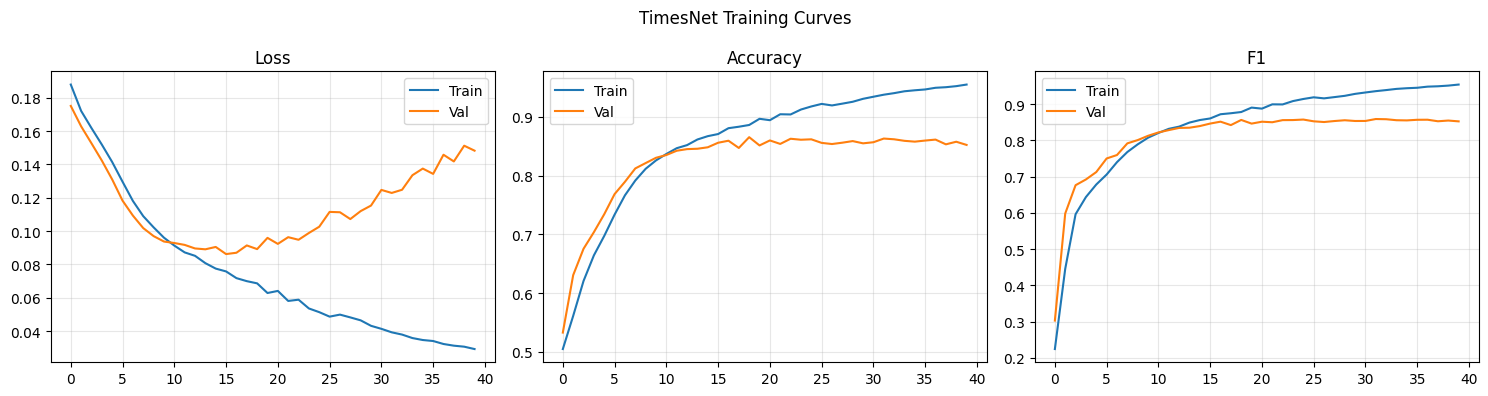

Model and scaler saved to: /content/timesnet_ckpt


In [ ]:
# ============================================================
# CELL 1 — TRAINING (TimesNet, fixed version)
# Upload: 8months_balanced_faults.xlsx, 8monthsdt_predictions.xlsx
# ============================================================

!pip install -q openpyxl

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# ── BASIC SETUP ──────────────────────────────────────────────
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_DIR = "/content/timesnet_ckpt"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Device: {DEVICE}")

# ── CONFIG ───────────────────────────────────────────────────
TRAIN_SENSOR_FILE = "/content/8monthsmultisensor_faults.xlsx"
TRAIN_DT_FILE     = "/content/8monthsdt_predictionsonly.xlsx"

SENSOR_COLS = ["T (degC)", "Tdew (degC)", "rh (%)"]
DT_COLS     = ["T_pred",   "Td_pred",     "RH_pred"]
TIMESTAMP   = "Date Time"
LABEL_COL   = "binary_label"

WINDOW_SIZE = 16
STRIDE      = 4
ROLL_W      = 6

# TimesNet params
D_MODEL    = 64
N_KERNELS  = 3
D_FF       = 126   # divisible by 3 for clean inception branches
N_LAYERS   = 2
DROPOUT    = 0.1

BATCH_SIZE = 256
EPOCHS     = 50
LR         = 1e-3
VAL_SPLIT  = 0.15
PATIENCE   = 8
SEED       = 42
NUM_WORKERS = 2
# ────────────────────────────────────────────────────────────

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── 1. LOAD AND ALIGN DATA ───────────────────────────────────
sens = pd.read_excel(TRAIN_SENSOR_FILE)
dt   = pd.read_excel(TRAIN_DT_FILE)

sens[TIMESTAMP] = pd.to_datetime(sens[TIMESTAMP], dayfirst=True)
dt[TIMESTAMP]   = pd.to_datetime(dt[TIMESTAMP])

df = pd.merge(
    sens[[TIMESTAMP] + SENSOR_COLS + [LABEL_COL]],
    dt[[TIMESTAMP] + DT_COLS],
    on=TIMESTAMP,
    how="inner"
).sort_values(TIMESTAMP).reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Label counts: {df[LABEL_COL].value_counts().to_dict()}")

# ── 2. FEATURE ENGINEERING ───────────────────────────────────
# 7 features per sensor × 3 sensors = 21 features total
def build_features(df, sensor_cols, dt_cols, roll_w):
    feat_cols = []

    for sc, dc in zip(sensor_cols, dt_cols):
        sensor = df[sc].astype(float)
        dt_pred = df[dc].astype(float)

        res = sensor - dt_pred

        feat_cols.append(res.values.astype(np.float32))                                      # residual
        feat_cols.append(res.abs().values.astype(np.float32))                                # abs residual
        feat_cols.append((res ** 2).values.astype(np.float32))                               # squared residual
        feat_cols.append(res.rolling(roll_w, min_periods=1).mean().values.astype(np.float32)) # rolling mean
        feat_cols.append(
            res.rolling(roll_w, min_periods=1).std().fillna(0).values.astype(np.float32)
        )                                                                                    # rolling std
        feat_cols.append(
            res.abs().rolling(roll_w, min_periods=1).max().values.astype(np.float32)
        )                                                                                    # rolling max abs
        feat_cols.append(sensor.diff().fillna(0).values.astype(np.float32))                 # raw sensor diff

    X = np.stack(feat_cols, axis=1)   # shape: (N, F)
    return X

X_raw = build_features(df, SENSOR_COLS, DT_COLS, ROLL_W)
y_all = df[LABEL_COL].astype(np.int64).values

N = len(df)
N_FEAT = X_raw.shape[1]

print(f"Feature matrix shape: {X_raw.shape}")

# ── 3. TRAIN/VAL SPLIT BEFORE SCALING (fix leakage) ─────────
# Time-ordered split is safer for sequence problems
split_idx = int((1 - VAL_SPLIT) * N)

X_train_raw = X_raw[:split_idx]
X_val_raw   = X_raw[split_idx:]

y_train_raw = y_all[:split_idx]
y_val_raw   = y_all[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val_scaled   = scaler.transform(X_val_raw).astype(np.float32)

pickle.dump(scaler, open(f"{SAVE_DIR}/scaler.pkl", "wb"))
pickle.dump(
    {
        "W": WINDOW_SIZE,
        "S": STRIDE,
        "F": N_FEAT,
        "ROLL_W": ROLL_W,
        "D": D_MODEL,
        "K": N_KERNELS,
        "FF": D_FF,
        "L": N_LAYERS,
        "DO": DROPOUT,
        "SENSOR_COLS": SENSOR_COLS,
        "DT_COLS": DT_COLS,
        "TIMESTAMP": TIMESTAMP,
        "LABEL_COL": LABEL_COL,
    },
    open(f"{SAVE_DIR}/cfg.pkl", "wb")
)

# ── 4. WINDOW DATASET ────────────────────────────────────────
class FaultDataset(Dataset):
    def __init__(self, X, y, W, S):
        wins = []
        labs = []

        if len(X) < W:
            raise ValueError(f"Dataset length {len(X)} is smaller than WINDOW_SIZE {W}")

        for start in range(0, len(X) - W + 1, S):
            end = start + W
            wins.append(X[start:end])   # (W, F)
            labs.append(y[start:end])   # (W,)

        self.X = torch.tensor(np.stack(wins), dtype=torch.float32)
        self.y = torch.tensor(np.stack(labs), dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FaultDataset(X_train_scaled, y_train_raw, WINDOW_SIZE, STRIDE)
val_ds   = FaultDataset(X_val_scaled,   y_val_raw,   WINDOW_SIZE, STRIDE)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train windows: {len(train_ds):,}")
print(f"Val windows:   {len(val_ds):,}")

# ── 5. TIMESNET ARCHITECTURE ─────────────────────────────────
class InceptionBlock(nn.Module):
    """
    2D Inception-style block with 3 parallel convolutions.
    Input : (B, d_model, rows, cols)
    Output: (B, d_model, rows, cols)
    """
    def __init__(self, d_model, d_ff):
        super().__init__()
        assert d_ff % 3 == 0, "d_ff must be divisible by 3"

        branch_ch = d_ff // 3

        self.conv1 = nn.Conv2d(d_model, branch_ch, kernel_size=(1, 1), padding="same")
        self.conv3 = nn.Conv2d(d_model, branch_ch, kernel_size=(1, 3), padding="same")
        self.conv5 = nn.Conv2d(d_model, branch_ch, kernel_size=(1, 5), padding="same")

        self.proj = nn.Conv2d(d_ff, d_model, kernel_size=(1, 1))
        self.norm = nn.BatchNorm2d(d_model)

    def forward(self, x):
        o1 = F.gelu(self.conv1(x))
        o3 = F.gelu(self.conv3(x))
        o5 = F.gelu(self.conv5(x))

        out = torch.cat([o1, o3, o5], dim=1)
        out = self.proj(out)
        out = self.norm(out)
        out = F.gelu(out)
        return out


class TimesBlock(nn.Module):
    """
    One TimesNet block:
      1. FFT over time axis to detect top-K periods
      2. Fold sequence into 2D grids using each detected period
      3. Apply 2D Inception block
      4. Unfold back to time axis
      5. Aggregate K branches
      6. Residual + LayerNorm
    """
    def __init__(self, W, d_model, d_ff, k):
        super().__init__()
        self.W = W
        self.k = k
        self.inception = InceptionBlock(d_model, d_ff)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B, W, D)
        B, W, D = x.shape

        # FFT over time dimension
        xf = torch.fft.rfft(x, dim=1)                 # (B, W//2+1, D)
        amps = xf.abs().mean(dim=(0, 2))              # global spectrum across batch and channels
        amps[0] = 0.0                                 # ignore DC

        max_freq_idx = amps.shape[0] - 1
        k = min(self.k, max_freq_idx)

        if k <= 0:
            return self.norm(x)

        top_k = amps.topk(k).indices                  # frequency bin indices

        # Better period calculation
        freq = top_k.float().clamp(min=1.0)
        periods = torch.div(W, freq, rounding_mode="floor").clamp(min=1, max=W).long()

        branch_outs = []
        branch_scores = amps[top_k].float()

        for p in periods:
            p = int(p.item())

            rows = (W + p - 1) // p
            padded_len = rows * p
            pad = padded_len - W

            # symmetric padding across time dimension
            pad_left = pad // 2
            pad_right = pad - pad_left

            # F.pad for 3D tensor (B, W, D): pad last dim first, then middle dim
            # (last_dim_left, last_dim_right, time_left, time_right)
            xp = F.pad(x, (0, 0, pad_left, pad_right))   # (B, W+pad, D)

            # reshape to 2D period grid
            xp2d = xp.reshape(B, rows, p, D).permute(0, 3, 1, 2)   # (B, D, rows, p)

            # 2D conv processing
            xp2d = self.inception(xp2d)

            # unfold back
            xp_out = xp2d.permute(0, 2, 3, 1).reshape(B, padded_len, D)

            # remove symmetric padding
            xp_out = xp_out[:, pad_left:pad_left + W, :]            # (B, W, D)
            branch_outs.append(xp_out)

        weights = F.softmax(branch_scores, dim=0)                   # (K,)
        out = sum(w * b for w, b in zip(weights, branch_outs))      # (B, W, D)

        return self.norm(out + x)


class TimesNet(nn.Module):
    """
    TimesNet for per-timestep binary classification.

    Input : (B, W, F)
    Output: (B, W, 2)
    """
    def __init__(self, n_feat, W, d_model, d_ff, k, n_layers, dropout):
        super().__init__()

        self.proj = nn.Sequential(
            nn.Linear(n_feat, d_model),
            nn.LayerNorm(d_model)
        )

        self.blocks = nn.ModuleList([
            TimesBlock(W, d_model, d_ff, k) for _ in range(n_layers)
        ])

        self.drop = nn.Dropout(dropout)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 2)
        )

    def forward(self, x):
        x = self.proj(x)      # (B, W, d_model)
        x = self.drop(x)

        for blk in self.blocks:
            x = blk(x)

        logits = self.head(x) # (B, W, 2)
        return logits


model = TimesNet(
    n_feat=N_FEAT,
    W=WINDOW_SIZE,
    d_model=D_MODEL,
    d_ff=D_FF,
    k=N_KERNELS,
    n_layers=N_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTimesNet | features={N_FEAT} | d={D_MODEL} | k={N_KERNELS} | layers={N_LAYERS} | params={n_params:,}")

# ── 6. LOSS / OPTIMIZER / SCHEDULER ──────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

criterion = FocalLoss(gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    steps_per_epoch=len(train_loader),
    epochs=EPOCHS
)

# ── 7. TRAIN / VALIDATION LOOP ───────────────────────────────
def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_preds = []
    all_true = []

    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)   # (B, W, F)
            yb = yb.to(DEVICE, non_blocking=True)   # (B, W)

            logits = model(xb)                      # (B, W, 2)
            B, W, C = logits.shape

            logits_flat = logits.reshape(B * W, C)
            yb_flat = yb.reshape(B * W)

            loss = criterion(logits_flat, yb_flat)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            total_loss += loss.item() * (B * W)

            preds = logits_flat.argmax(dim=1).detach().cpu()
            true_ = yb_flat.detach().cpu()

            all_preds.append(preds)
            all_true.append(true_)

    all_preds = torch.cat(all_preds).numpy()
    all_true = torch.cat(all_true).numpy()

    avg_loss = total_loss / len(all_true)
    acc = (all_preds == all_true).mean()
    f1 = f1_score(all_true, all_preds, zero_division=0)

    return avg_loss, acc, f1

hist = {
    "tl": [], "ta": [], "tf": [],
    "vl": [], "va": [], "vf": []
}

best_f1 = -1.0
pat = 0

print(f'\n{"Ep":>4} | {"TrLoss":>8} {"TrAcc":>7} {"TrF1":>7} | {"VaLoss":>8} {"VaAcc":>7} {"VaF1":>7}')
print("─" * 68)

for ep in range(1, EPOCHS + 1):
    tl, ta, tf = run_epoch(train_loader, train=True)
    vl, va, vf = run_epoch(val_loader, train=False)

    hist["tl"].append(tl)
    hist["ta"].append(ta)
    hist["tf"].append(tf)
    hist["vl"].append(vl)
    hist["va"].append(va)
    hist["vf"].append(vf)

    print(f"{ep:>4} | {tl:>8.4f} {ta:>6.2%} {tf:>7.4f} | {vl:>8.4f} {va:>6.2%} {vf:>7.4f}", end="")

    if vf > best_f1:
        best_f1 = vf
        torch.save(model.state_dict(), f"{SAVE_DIR}/best_model.pt")
        pat = 0
        print("  ✔")
    else:
        pat += 1
        print(f"  ({pat}/{PATIENCE})")
        if pat >= PATIENCE:
            print(f"Early stopping at epoch {ep}")
            break

print(f"\nBest validation F1: {best_f1:.4f}")

# ── 8. TRAINING CURVES ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (train_key, val_key, title) in zip(
    axes,
    [("tl", "vl", "Loss"), ("ta", "va", "Accuracy"), ("tf", "vf", "F1")]
):
    ax.plot(hist[train_key], label="Train")
    ax.plot(hist[val_key], label="Val")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("TimesNet Training Curves")
plt.tight_layout()
plt.show()

print(f"Model and scaler saved to: {SAVE_DIR}")

In [ ]:
import pandas as pd
import numpy as np
import torch
import pickle
from torch.utils.data import Dataset, DataLoader

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVE_DIR = '/content/timesnet_ckpt'

# ---- Load config + scaler ----
cfg = pickle.load(open(f'{SAVE_DIR}/cfg.pkl', 'rb'))
scaler = pickle.load(open(f'{SAVE_DIR}/scaler.pkl', 'rb'))

WINDOW_SIZE = cfg['W']
STRIDE      = cfg['S']
N_FEAT      = cfg['F']
ROLL_W      = cfg['ROLL_W']

SENSOR_COLS = cfg['SENSOR_COLS']
DT_COLS     = cfg['DT_COLS']
TIMESTAMP   = cfg['TIMESTAMP']

# ---- Load model ----
model = TimesNet(
    n_feat=N_FEAT,
    W=WINDOW_SIZE,
    d_model=cfg['D'],
    d_ff=cfg['FF'],
    k=cfg['K'],
    n_layers=cfg['L'],
    dropout=cfg['DO']
).to(DEVICE)

model.load_state_dict(torch.load(f'{SAVE_DIR}/best_model.pt', map_location=DEVICE))
model.eval()

print("Model loaded")

# ---- Load test data ----
TEST_SENSOR_FILE = '/content/testmultisensor_faults no labels.xlsx'
TEST_DT_FILE     = '/content/dt_test_predictionsonly.xlsx'

sens = pd.read_excel(TEST_SENSOR_FILE)
dt   = pd.read_excel(TEST_DT_FILE)

sens[TIMESTAMP] = pd.to_datetime(sens[TIMESTAMP], dayfirst=True)
dt[TIMESTAMP]   = pd.to_datetime(dt[TIMESTAMP])

df = pd.merge(
    sens[[TIMESTAMP] + SENSOR_COLS],
    dt[[TIMESTAMP] + DT_COLS],
    on=TIMESTAMP,
    how='inner'
).sort_values(TIMESTAMP).reset_index(drop=True)

print(f'Test rows: {len(df)}')

# ---- Feature engineering (same as training) ----
def build_features(df, sensor_cols, dt_cols, roll_w):
    cols = []
    for sc, dc in zip(sensor_cols, dt_cols):
        res = df[sc] - df[dc]
        cols += [
            res.values,
            np.abs(res.values),
            (res.values ** 2),
            res.rolling(roll_w, min_periods=1).mean().values,
            res.rolling(roll_w, min_periods=1).std().fillna(0).values,
            np.abs(res).rolling(roll_w, min_periods=1).max().values,
            df[sc].diff().fillna(0).values
        ]
    return np.stack(cols, axis=1).astype(np.float32)

X_raw = build_features(df, SENSOR_COLS, DT_COLS, ROLL_W)
X_scaled = scaler.transform(X_raw).astype(np.float32)

# ---- Dataset ----
class TestDataset(Dataset):
    def __init__(self, X, W, S):
        self.windows = []
        self.indices = []
        for i in range(0, len(X) - W + 1, S):
            self.windows.append(X[i:i+W])
            self.indices.append(i)
        self.X = torch.tensor(np.stack(self.windows), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.indices[idx]

test_ds = TestDataset(X_scaled, WINDOW_SIZE, STRIDE)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

# ---- Inference ----
all_preds = np.zeros(len(df))
counts    = np.zeros(len(df))

with torch.no_grad():
    for xb, idxs in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)                 # (B, W, 2)
        preds  = logits.argmax(dim=2).cpu().numpy()

        for i, start in enumerate(idxs):
            start = int(start)
            all_preds[start:start+WINDOW_SIZE] += preds[i]
            counts[start:start+WINDOW_SIZE] += 1

# ---- Aggregate overlapping predictions ----
final_preds = (all_preds / counts) >= 0.5
final_preds = final_preds.astype(int)

df['predicted_label'] = final_preds

# ---- Save predictions ----
PRED_FILE = '/content/timesnet predictions.xlsx'
df.to_excel(PRED_FILE, index=False)

print(f' TimesNet Predictions saved to {PRED_FILE}')

Model loaded
Test rows: 3120
 TimesNet Predictions saved to /content/timesnet predictions.xlsx


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---- File paths ----
PRED_FILE = '/content/timesnet predictions.xlsx'
GT_FILE   = '/content/testmultisensor_faults.xlsx'

TIMESTAMP = 'Date Time'
LABEL_COL = 'binary_label'

# ---- Load predictions ----
pred_df = pd.read_excel(PRED_FILE)
pred_df[TIMESTAMP] = pd.to_datetime(pred_df[TIMESTAMP])

# ---- Load ground truth ----
gt_df = pd.read_excel(GT_FILE)
gt_df[TIMESTAMP] = pd.to_datetime(gt_df[TIMESTAMP], dayfirst=True)

# ---- Merge on timestamp ----
df_eval = pd.merge(
    pred_df[[TIMESTAMP, 'predicted_label']],
    gt_df[[TIMESTAMP, LABEL_COL]],
    on=TIMESTAMP,
    how='inner'
)

print(f"Matched rows for evaluation: {len(df_eval)}")

# ---- Extract labels ----
y_true = df_eval[LABEL_COL].values
y_pred = df_eval['predicted_label'].values

# ---- Metrics ----
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)

print("\n Evaluation Metrics")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


Matched rows for evaluation: 3120

 Evaluation Metrics
Accuracy : 0.8667
Precision: 0.8942
Recall   : 0.8325
F1 Score : 0.8623


In [ ]:
!pip install -q transformers torch scikit-learn pandas numpy openpyxl

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from transformers import AutoModel, AutoConfig
import joblib

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================
# Load training data
# ==========================
sensor_df = pd.read_excel("/content/8monthsmultisensor_faults.xlsx")
dt_df = pd.read_excel("/content/8monthsdt_predictionsonly.xlsx")

sensor_df["Date Time"] = pd.to_datetime(sensor_df["Date Time"], dayfirst=True)
dt_df["Date Time"] = pd.to_datetime(dt_df["Date Time"], dayfirst=True)

df = sensor_df.merge(dt_df, on="Date Time")

# ==========================
# Residual features
# ==========================
df["res_T"]  = df["T (degC)"] - df["T_pred"]
df["res_Td"] = df["Tdew (degC)"] - df["Td_pred"]
df["res_RH"] = df["rh (%)"] - df["RH_pred"]

df["res_mag"] = np.sqrt(
    df["res_T"]**2 +
    df["res_Td"]**2 +
    df["res_RH"]**2
)

features = [
    "T (degC)", "Tdew (degC)", "rh (%)",
    "T_pred","Td_pred","RH_pred",
    "res_T","res_Td","res_RH","res_mag"
]

X = df[features].values
y = df["binary_label"].values

# ==========================
# Scale
# ==========================
scaler = StandardScaler()
X = scaler.fit_transform(X)

joblib.dump(scaler,"transformer_scaler.pkl")

# ==========================
# Window dataset
# ==========================
WINDOW = 12

class TimeDataset(Dataset):
    def __init__(self,X,y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X) - WINDOW

    def __getitem__(self,idx):
        x = self.X[idx:idx+WINDOW]
        label = self.y[idx+WINDOW]
        return torch.tensor(x,dtype=torch.float32),torch.tensor(label)

dataset = TimeDataset(X,y)
loader = DataLoader(dataset,batch_size=32,shuffle=True)

# ==========================
# Transformer classifier
# ==========================
class TransformerClassifier(nn.Module):

    def __init__(self,model_name,input_dim):

        super().__init__()

        config = AutoConfig.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name)

        self.input_proj = nn.Linear(input_dim,config.hidden_size)

        self.classifier = nn.Linear(config.hidden_size,2)

    def forward(self,x):

        x = self.input_proj(x)

        outputs = self.backbone(inputs_embeds=x)

        cls = outputs.last_hidden_state[:,0]

        return self.classifier(cls)

# ==========================
# Train models
# ==========================
models = [
    "distilbert-base-uncased",
    "roberta-base",
    "huawei-noah/TinyBERT_General_4L_312D"
]

for name in models:

    print("Training",name)

    model = TransformerClassifier(name,len(features)).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(),lr=2e-5)

    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(3):

        total=0

        for x_batch,y_batch in loader:

            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()

            logits = model(x_batch)

            loss = loss_fn(logits,y_batch)

            loss.backward()

            optimizer.step()

            total+=loss.item()

        print("Epoch",epoch,"Loss",total/len(loader))

    torch.save(model.state_dict(),name.replace("/","_")+"_model.pt")

Training distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Epoch 0 Loss 0.694441930848894
Epoch 1 Loss 0.6939618738412421
Epoch 2 Loss 0.6932550838704084


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score,recall_score,f1_score
import joblib

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ==========================
# Load test data
# ==========================
sensor_df = pd.read_excel("/content/testmultisensor_faults no labels.xlsx")
dt_df = pd.read_excel("/content/dt_test_predictionsonly.xlsx")

sensor_df["Date Time"] = pd.to_datetime(sensor_df["Date Time"],dayfirst=True)
dt_df["Date Time"] = pd.to_datetime(dt_df["Date Time"],dayfirst=True)

df = sensor_df.merge(dt_df,on="Date Time")

# residuals
df["res_T"]  = df["T (degC)"] - df["T_pred"]
df["res_Td"] = df["Tdew (degC)"] - df["Td_pred"]
df["res_RH"] = df["rh (%)"] - df["RH_pred"]

df["res_mag"] = np.sqrt(
    df["res_T"]**2 +
    df["res_Td"]**2 +
    df["res_RH"]**2
)

features = [
    "T (degC)", "Tdew (degC)", "rh (%)",
    "T_pred","Td_pred","RH_pred",
    "res_T","res_Td","res_RH","res_mag"
]

scaler = joblib.load("transformer_scaler.pkl")

X = scaler.transform(df[features].values)

# ==========================
# Window dataset
# ==========================
WINDOW = 12

class TestDataset(torch.utils.data.Dataset):

    def __init__(self,X):
        self.X = X

    def __len__(self):
        return len(self.X)-WINDOW

    def __getitem__(self,idx):
        return torch.tensor(self.X[idx:idx+WINDOW],dtype=torch.float32)

test_ds = TestDataset(X)

loader = torch.utils.data.DataLoader(test_ds,batch_size=32)

# ==========================
# Evaluate models
# ==========================
true_df = pd.read_excel("/content/testmultisensor_faults.xlsx")

y_true = true_df["binary_label"].values[WINDOW:WINDOW+len(preds)]

models = [
    "distilbert-base-uncased",
    "roberta-base",
    "huawei-noah/TinyBERT_General_4L_312D"
]

for name in models:

    print("\nModel:",name)

    model = TransformerClassifier(name,len(features)).to(DEVICE)

    model.load_state_dict(torch.load(name.replace("/","_")+"_model.pt"))

    model.eval()

    preds=[]

    with torch.no_grad():

        for x_batch in loader:

            x_batch = x_batch.to(DEVICE)

            logits = model(x_batch)

            p = torch.argmax(logits,dim=1)

            preds.extend(p.cpu().numpy())

    acc = accuracy_score(y_true,preds)

    rec = recall_score(y_true,preds)

    f1 = f1_score(y_true,preds)

    print("Accuracy:",acc)
    print("Recall:",rec)
    print("F1:",f1)